In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os
from os.path import join
import json
import pickle as pkl
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from tqdm.auto import trange, tqdm
import numpy as np
import matplotlib.pyplot as plt
from easydict import EasyDict as edict
sys.path.append("/n/home12/binxuwang/Github/DiffusionLearningCurve")
sys.path.append("/Users/binxuwang/Github/DiffusionLearningCurve/")
from core.diffusion_nn_lib import UNetBlockStyleMLP_backbone
from core.toy_shape_dataset_lib import generate_random_star_shape_torch
from core.diffusion_basics_lib import *
from core.diffusion_edm_lib import *
from core.network_edm_lib import SongUNet, DhariwalUNet
from core.DiT_model_lib import *
from core.diffusion_nn_lib import UNetBlockStyleMLP_backbone
from circuit_toolkit.plot_utils import saveallforms, to_imgrid, show_imgrid
from pprint import pprint

saveroot = f"/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionSpectralLearningCurve"

In [3]:
import PIL
from core.model_eval_utils import load_pretrained_model
from core.dataset_lib import load_dataset

In [5]:
device = "cuda"

In [4]:
Xtsr_raw, imgsize = load_dataset("MNIST", normalize=False)
Xtsr, imgsize = load_dataset("MNIST", normalize=True)

MNIST dataset: torch.Size([60000, 1, 32, 32])
Raw value range 0.9921568632125854 0.0
MNIST dataset: torch.Size([60000, 1, 32, 32])
Raw value range 0.9921568632125854 0.0
Normalizing dataset to [-1.0, 1.0]


In [ ]:
Xtsr = Xtsr.to(device)
Xtsr_raw = Xtsr_raw.to(device)
Xmat = Xtsr.flatten(start_dim=1)
Xcov = torch.cov(Xmat.T)
Xmean = Xmat.mean(dim=0)
eigvals, eigvecs = torch.linalg.eigh(Xcov)

In [9]:
device = "cuda"
expname = "MNIST_UNet_CNN_EDM_4blocks_noattn"
expname = "MNIST_UNet_CNN_EDM_4blocks_wide64_noattn"
# expname = "MNIST_UNet_CNN_EDM_shallow"
CNN_precd, model, config = load_pretrained_model(expname, device="cuda")

Loading CNN UNet model with config:  {'channels': 1, 'img_size': 32, 'layers_per_block': 1, 'decoder_init_attn': True, 'attn_resolutions': [], 'model_channels': 64, 'channel_mult': [1, 2, 3, 4], 'dropout': 0.0, 'label_dim': 0, 'augment_dim': 0}
total number of trainable parameters in the Score Model: 15916417
total number of parameters in the Score Model: 15916417
Total number of parameters in the model: 15916417 | trainable: 15916417


### Loading noise seed


In [7]:
init_noise = torch.load("/n/home12/binxuwang/Github/DiffusionLearningCurve/notebook/fixed_latents_seed111.pt")

/tmp/ipykernel_71547/1726048718.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  init_noise = torch.load("/n/home12/binxuwang/Github/DiffusionLearningCurve/notebook/fixed

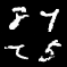

In [13]:
x_out_i = edm_sampler(CNN_precd, init_noise.to(device), num_steps=40, 
            sigma_min=0.002, sigma_max=80.0, rho=7, return_traj=False)
to_imgrid(((x_out_i.cpu()+1)/2).clamp(0, 1), padding=1, nrow=2)#.resize((64, 64), resample=PIL.Image.Resampling.NEAREST)

In [ ]:
expnames = [
    # "MNIST_MLP_EDM",
    # "MNIST_MLP_EDM_width1024_small_lr_long_train",
    # "MNIST_UNet_CNN_EDM",
    "MNIST_UNet_CNN_EDM_1block_noattn",
    "MNIST_UNet_CNN_EDM_1block_wide128_noattn",
    "MNIST_UNet_CNN_EDM_2blocks_noattn",
    "MNIST_UNet_CNN_EDM_4blocks_noattn",
    "MNIST_UNet_CNN_EDM_4blocks_noattn_denser",
    "MNIST_UNet_CNN_EDM_4blocks_noattn_smalllr",
    "MNIST_UNet_CNN_EDM_4blocks_noattn_smalllr_longtrain",
    "MNIST_UNet_CNN_EDM_4blocks_wide64_noattn",
    "MNIST_UNet_CNN_EDM_deeper_1block_noattn",
    "MNIST_UNet_CNN_EDM_shallow",
    "MNIST_UNet_CNN_EDM_shallow_1block_noattn",
]
init_noise = torch.load("/n/home12/binxuwang/Github/DiffusionLearningCurve/notebook/fixed_latents_seed111.pt")
for expname in expnames:
    try:
        CNN_precd, model, config = load_pretrained_model(expname, device="cuda")
        print(f"Loaded {expname} model")
        print(f"Model config: {config}")
        print("UNet denoiser")
        x_out_i = edm_sampler(CNN_precd, init_noise.to(device), num_steps=40, 
                sigma_min=0.002, sigma_max=80.0, rho=7, return_traj=False)
        mtg = to_imgrid(((x_out_i.cpu()+1)/2).clamp(0, 1), padding=1, nrow=2)#.resize((64, 64), resample=PIL.Image.Resampling.NEAREST)
        mtg.save(f"/n/home12/binxuwang/Github/DiffusionLearningCurve/notebook/UNet_generation_comparison/MNIST_{expname}_seed111.png")
    except Exception as e:
        print(f"Failed to load {expname}: {e}")
        continue


Loading CNN UNet model with config:  {'channels': 1, 'img_size': 32, 'layers_per_block': 1, 'decoder_init_attn': True, 'attn_resolutions': [], 'model_channels': 16, 'channel_mult': [1], 'dropout': 0.0, 'label_dim': 0, 'augment_dim': 0}
total number of trainable parameters in the Score Model: 41153
total number of parameters in the Score Model: 41153
Total number of parameters in the model: 41153 | trainable: 41153
Loading CNN UNet model with config:  {'channels': 1, 'img_size': 32, 'layers_per_block': 1, 'decoder_init_attn': True, 'attn_resolutions': [], 'model_channels': 128, 'channel_mult': [1], 'dropout': 0.0, 'label_dim': 0, 'augment_dim': 0}
total number of trainable parameters in the Score Model: 2565633
total number of parameters in the Score Model: 2565633
Failed to load MNIST_UNet_CNN_EDM_1block_wide128_noattn: [Errno 2] No such file or directory: '/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionSpectralLearningCurve/MNIST_UNet_CNN_EDM_1block_wi

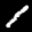

In [9]:
seed = 1234
noise_init = torch.randn(1, 1, 32, 32, generator=torch.Generator(device=device).manual_seed(seed), device=device)
x_out_i = edm_sampler(CNN_precd, noise_init, num_steps=25, 
            sigma_min=0.002, sigma_max=80.0, rho=7, return_traj=False)
to_imgrid(((x_out_i.cpu()+1)/2).clamp(0, 1), padding=1)#.resize((64, 64), resample=PIL.Image.Resampling.NEAREST)

In [10]:
mnist_mean, mnist_std = 0.1307, 0.3081

In [13]:
# Create normalization transform for MNIST
mnist_normalize = transforms.Normalize(mean=mnist_mean, std=mnist_std)
mnist_denormalize = transforms.Normalize(mean=-mnist_mean/mnist_std, std=1/mnist_std)
mine_normalize = transforms.Normalize(mean=0.5, std=0.5)
mine_denormalize = transforms.Normalize(mean=-0.5/0.5, std=1/0.5)

In [23]:
sigma = 2
Xprobe = Xtsr_raw[:2000]
Xprobe_emma_norm = mnist_normalize(Xprobe)
noise_init = torch.randn(Xprobe_emma_norm.shape, generator=torch.Generator(device=device).manual_seed(seed), device=device)
Xnoised_emma_norm = (Xprobe_emma_norm + sigma * noise_init)
Xnoised = mnist_denormalize(Xnoised_emma_norm)
Xnoised_BW_norm = mine_normalize(Xnoised)
Xnoised_BW_denorm = mine_denormalize(Xnoised_BW_norm)

In [24]:
torch.cuda.empty_cache()

In [25]:
with torch.no_grad():
    sigma_vec = torch.ones(Xnoised_BW_norm.shape[0], device=device) * sigma
    denoised_X_BW_norm = CNN_precd(Xnoised_BW_norm, sigma_vec)
    denoised_X_BW_denorm = mine_denormalize(denoised_X_BW_norm)
torch.cuda.empty_cache()

In [28]:
MSE_noclip = (denoised_X_BW_denorm - Xprobe).pow(2).mean()
MSE_clip = (denoised_X_BW_denorm.clamp(0, 1) - Xprobe).pow(2).mean()
print(f"sigma {sigma}", "MSE (noclip)", MSE_noclip.item(), "MSE (clip)", MSE_clip.item())

sigma 2 MSE (noclip) 0.006602446082979441 MSE (clip) 0.006555529776960611


In [30]:
print("UNet denoiser")
Xprobe = Xtsr_raw[:2000]
noise_init = torch.randn(Xprobe_emma_norm.shape, generator=torch.Generator(device=device).manual_seed(seed), device=device)
Xprobe_emma_norm = mnist_normalize(Xprobe)
for sigma in [1, 2, 3, 4]:
    Xnoised_emma_norm = (Xprobe_emma_norm + sigma * noise_init)
    Xnoised = mnist_denormalize(Xnoised_emma_norm)
    Xnoised_BW_norm = mine_normalize(Xnoised)
    Xnoised_BW_denorm = mine_denormalize(Xnoised_BW_norm)
    with torch.no_grad():
        sigma_vec = torch.ones(Xnoised_BW_norm.shape[0], device=device) * sigma
        denoised_X_BW_norm = CNN_precd(Xnoised_BW_norm, sigma_vec)
        denoised_X_BW_denorm = mine_denormalize(denoised_X_BW_norm)
    torch.cuda.empty_cache()
    MSE_noclip = (denoised_X_BW_denorm - Xprobe).pow(2).mean()
    MSE_clip = (denoised_X_BW_denorm.clamp(0, 1) - Xprobe).pow(2).mean()
    print(f"sigma {sigma}", "MSE (noclip)", MSE_noclip.item(), "MSE (clip)", MSE_clip.item())

UNet denoiser
sigma 1 MSE (noclip) 0.0026094047352671623 MSE (clip) 0.0025338539853692055
sigma 2 MSE (noclip) 0.006602446082979441 MSE (clip) 0.006555529776960611
sigma 3 MSE (noclip) 0.01229628175497055 MSE (clip) 0.01225445605814457
sigma 4 MSE (noclip) 0.019162433221936226 MSE (clip) 0.019121108576655388


In [ ]:
device = "cuda"
expname = "MNIST_UNet_CNN_EDM_4blocks_noattn"
expname = "MNIST_UNet_CNN_EDM_4blocks_wide64_noattn"
# expname = "MNIST_UNet_CNN_EDM_shallow"
for expname in ["MNIST_UNet_CNN_EDM_4blocks_noattn", "MNIST_UNet_CNN_EDM_4blocks_wide64_noattn", "MNIST_UNet_CNN_EDM_shallow"]:
CNN_precd, model, config = load_pretrained_model(expname, device="cuda")

In [33]:
!ls -d /n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionSpectralLearningCurve/MNIST* | xargs -n 1 basename

MNIST_MLP_EDM
MNIST_MLP_EDM_width1024_small_lr_long_train
MNIST_UNet_CNN_EDM
MNIST_UNet_CNN_EDM_1block_noattn
MNIST_UNet_CNN_EDM_1block_wide128_noattn
MNIST_UNet_CNN_EDM_2blocks_noattn
MNIST_UNet_CNN_EDM_4blocks_noattn
MNIST_UNet_CNN_EDM_4blocks_noattn_denser
MNIST_UNet_CNN_EDM_4blocks_noattn_smalllr
MNIST_UNet_CNN_EDM_4blocks_noattn_smalllr_longtrain
MNIST_UNet_CNN_EDM_4blocks_wide64_noattn
MNIST_UNet_CNN_EDM_deeper_1block_noattn
MNIST_UNet_CNN_EDM_shallow
MNIST_UNet_CNN_EDM_shallow_1block_noattn


In [ ]:
# \mathbf{x}+\sigma^{2}(\Sigma+\sigma^{2}I)^{-1}(\mu-\mathbf{x})
def linear_denoiser(Xnoised, sigma, Xmean, Xeigvals, Xeigvecs):
    imgshape = Xnoised.shape[1:]
    Xnoised_mat = Xnoised.flatten(start_dim=1)
    Xnoised_demean = (Xmean - Xnoised_mat) @ Xeigvecs
    scaling = sigma**2 / (Xeigvals + sigma**2)
    Xnoised_proj = Xnoised_demean * scaling[None,:]
    Xnoised_mat = Xnoised_mat + Xnoised_proj @ Xeigvecs.T
    Xdenoised = Xnoised_mat.reshape(-1, *imgshape)
    return Xdenoised

In [ ]:
expnames = [
    "MNIST_MLP_EDM",
    "MNIST_MLP_EDM_width1024_small_lr_long_train",
    "MNIST_UNet_CNN_EDM",
    "MNIST_UNet_CNN_EDM_1block_noattn",
    "MNIST_UNet_CNN_EDM_1block_wide128_noattn",
    "MNIST_UNet_CNN_EDM_2blocks_noattn",
    "MNIST_UNet_CNN_EDM_4blocks_noattn",
    "MNIST_UNet_CNN_EDM_4blocks_noattn_denser",
    "MNIST_UNet_CNN_EDM_4blocks_noattn_smalllr",
    "MNIST_UNet_CNN_EDM_4blocks_noattn_smalllr_longtrain",
    "MNIST_UNet_CNN_EDM_4blocks_wide64_noattn",
    "MNIST_UNet_CNN_EDM_deeper_1block_noattn",
    "MNIST_UNet_CNN_EDM_shallow",
    "MNIST_UNet_CNN_EDM_shallow_1block_noattn",
]
for expname in expnames:
    try:
        CNN_precd, model, config = load_pretrained_model(expname, device="cuda")
        print(f"Loaded {expname} model")
        print(f"Model config: {config}")
        print("UNet denoiser")
        Xprobe = Xtsr_raw[:2500]
        noise_init = torch.randn(Xprobe_emma_norm.shape, generator=torch.Generator(device=device).manual_seed(seed), device=device)
        Xprobe_emma_norm = mnist_normalize(Xprobe)
        for sigma in [1, 2, 3, 4]:
            Xnoised_emma_norm = (Xprobe_emma_norm + sigma * noise_init)
            Xnoised = mnist_denormalize(Xnoised_emma_norm)
            Xnoised_BW_norm = mine_normalize(Xnoised)
            Xnoised_BW_denorm = mine_denormalize(Xnoised_BW_norm)
            with torch.no_grad():
                sigma_vec = torch.ones(Xnoised_BW_norm.shape[0], device=device) * sigma
                denoised_X_BW_norm = CNN_precd(Xnoised_BW_norm, sigma_vec)
                denoised_X_BW_denorm = mine_denormalize(denoised_X_BW_norm)
            torch.cuda.empty_cache()
            MSE_noclip = (denoised_X_BW_denorm - Xprobe).pow(2).mean()
            MSE_clip = (denoised_X_BW_denorm.clamp(0, 1) - Xprobe).pow(2).mean()
            print(f"sigma {sigma}", "MSE (noclip)", MSE_noclip.item(), "MSE (clip)", MSE_clip.item())
        print("======================\n")
    except Exception as e:
        continue

for sigma in [1, 2, 3, 4]:
    Xnoised_emma_norm = (Xprobe_emma_norm + sigma * noise_init)
    Xnoised = mnist_denormalize(Xnoised_emma_norm)
    Xnoised_BW_norm = mine_normalize(Xnoised)
    Xnoised_BW_denorm = mine_denormalize(Xnoised_BW_norm)
    with torch.no_grad():
        denoised_X_BW_norm = linear_denoiser(Xnoised_BW_norm, sigma, Xmean, eigvals, eigvecs)
        denoised_X_BW_denorm = mine_denormalize(denoised_X_BW_norm)
    torch.cuda.empty_cache()
    MSE_noclip = (denoised_X_BW_denorm - Xprobe).pow(2).mean()
    MSE_clip = (denoised_X_BW_denorm.clamp(0, 1) - Xprobe).pow(2).mean()
    print(f"sigma {sigma}", "MSE (noclip)", MSE_noclip.item(), "MSE (clip)", MSE_clip.item())

Loading CNN UNet model with config:  {'channels': 1, 'img_size': 32, 'layers_per_block': 1, 'decoder_init_attn': True, 'attn_resolutions': [], 'model_channels': 16, 'channel_mult': [1], 'dropout': 0.0, 'label_dim': 0, 'augment_dim': 0}
total number of trainable parameters in the Score Model: 41153
total number of parameters in the Score Model: 41153
Total number of parameters in the model: 41153 | trainable: 41153
Loaded MNIST_UNet_CNN_EDM_1block_noattn model
Model config: {'channels': 1, 'img_size': 32, 'layers_per_block': 1, 'decoder_init_attn': True, 'attn_resolutions': [], 'model_channels': 16, 'channel_mult': [1], 'dropout': 0.0, 'label_dim': 0, 'augment_dim': 0}
UNet denoiser
sigma 1 MSE (noclip) 0.00346780545078218 MSE (clip) 0.0034384895116090775
sigma 2 MSE (noclip) 0.011034544557332993 MSE (clip) 0.010996149852871895
sigma 3 MSE (noclip) 0.021625863388180733 MSE (clip) 0.021591510623693466
sigma 4 MSE (noclip) 0.03120780549943447 MSE (clip) 0.03117842972278595

Loading CNN UN

In [47]:
import pandas as pd

results = []
expnames = [
    "MNIST_MLP_EDM",
    "MNIST_MLP_EDM_width1024_small_lr_long_train",
    "MNIST_UNet_CNN_EDM",
    "MNIST_UNet_CNN_EDM_1block_noattn",
    "MNIST_UNet_CNN_EDM_1block_wide128_noattn",
    "MNIST_UNet_CNN_EDM_2blocks_noattn",
    "MNIST_UNet_CNN_EDM_4blocks_noattn",
    "MNIST_UNet_CNN_EDM_4blocks_noattn_denser",
    "MNIST_UNet_CNN_EDM_4blocks_noattn_smalllr",
    "MNIST_UNet_CNN_EDM_4blocks_noattn_smalllr_longtrain",
    "MNIST_UNet_CNN_EDM_4blocks_wide64_noattn",
    "MNIST_UNet_CNN_EDM_deeper_1block_noattn",
    "MNIST_UNet_CNN_EDM_shallow",
    "MNIST_UNet_CNN_EDM_shallow_1block_noattn",
]

Xprobe = Xtsr_raw[:2500]
noise_init = torch.randn(Xprobe_emma_norm.shape, generator=torch.Generator(device=device).manual_seed(seed), device=device)
print("Linear Wiener")
for sigma in [1, 2, 3, 4]:
    Xnoised_emma_norm = (Xprobe_emma_norm + sigma * noise_init)
    Xnoised = mnist_denormalize(Xnoised_emma_norm)
    Xnoised_BW_norm = mine_normalize(Xnoised)
    Xnoised_BW_denorm = mine_denormalize(Xnoised_BW_norm)
    with torch.no_grad():
        denoised_X_BW_norm = linear_denoiser(Xnoised_BW_norm, sigma, Xmean, eigvals, eigvecs)
        denoised_X_BW_denorm = mine_denormalize(denoised_X_BW_norm)
    torch.cuda.empty_cache()
    MSE_noclip = (denoised_X_BW_denorm - Xprobe).pow(2).mean()
    MSE_clip = (denoised_X_BW_denorm.clamp(0, 1) - Xprobe).pow(2).mean()
    print(f"sigma {sigma}", "MSE (noclip)", MSE_noclip.item(), "MSE (clip)", MSE_clip.item())
    result_row = {
                'expname': "LinearWiener",
                'sigma': sigma,
                'MSE_noclip': MSE_noclip.item(),
                'MSE_clip': MSE_clip.item()
            }
    results.append(result_row)
for expname in expnames:
    try:
        CNN_precd, model, config = load_pretrained_model(expname, device="cuda")
        print(f"Loaded {expname} model")
        print(f"Model config: {config}")
        print("UNet denoiser")
        Xprobe_emma_norm = mnist_normalize(Xprobe)
        for sigma in [1, 2, 3, 4]:
            Xnoised_emma_norm = (Xprobe_emma_norm + sigma * noise_init)
            Xnoised = mnist_denormalize(Xnoised_emma_norm)
            Xnoised_BW_norm = mine_normalize(Xnoised)
            Xnoised_BW_denorm = mine_denormalize(Xnoised_BW_norm)
            with torch.no_grad():
                sigma_vec = torch.ones(Xnoised_BW_norm.shape[0], device=device) * sigma
                denoised_X_BW_norm = CNN_precd(Xnoised_BW_norm, sigma_vec)
                denoised_X_BW_denorm = mine_denormalize(denoised_X_BW_norm)
            torch.cuda.empty_cache()
            MSE_noclip = (denoised_X_BW_denorm - Xprobe).pow(2).mean()
            MSE_clip = (denoised_X_BW_denorm.clamp(0, 1) - Xprobe).pow(2).mean()
            print(f"sigma {sigma}", "MSE (noclip)", MSE_noclip.item(), "MSE (clip)", MSE_clip.item())
            
            # Append results to list
            result_row = {
                'expname': expname,
                'sigma': sigma,
                'MSE_noclip': MSE_noclip.item(),
                'MSE_clip': MSE_clip.item()
            }
            # Add config parameters to the row
            for key, value in config.items():
                result_row[f'config_{key}'] = value
            results.append(result_row)
        print("======================\n")
    except Exception as e:
        print(f"Failed to load {expname}: {e}")
        continue

# Convert to DataFrame for better organization
results_df = pd.DataFrame(results)
print("\nOrganized Results:")
print(results_df.to_string(index=False))

Linear Wiener
sigma 1 MSE (noclip) 0.009233000688254833 MSE (clip) 0.008680399507284164
sigma 2 MSE (noclip) 0.01888812892138958 MSE (clip) 0.018532194197177887
sigma 3 MSE (noclip) 0.026778845116496086 MSE (clip) 0.026602281257510185
sigma 4 MSE (noclip) 0.03295881301164627 MSE (clip) 0.032876156270504
Failed to load MNIST_MLP_EDM: [Errno 2] No such file or directory: '/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionSpectralLearningCurve/MNIST_MLP_EDM/config.json'
Failed to load MNIST_MLP_EDM_width1024_small_lr_long_train: [Errno 2] No such file or directory: '/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionSpectralLearningCurve/MNIST_MLP_EDM_width1024_small_lr_long_train/config.json'
Failed to load MNIST_UNet_CNN_EDM: [Errno 2] No such file or directory: '/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionSpectralLearningCurve/MNIST_UNet_CNN_EDM/config.json'
Loading CNN UNet model with config

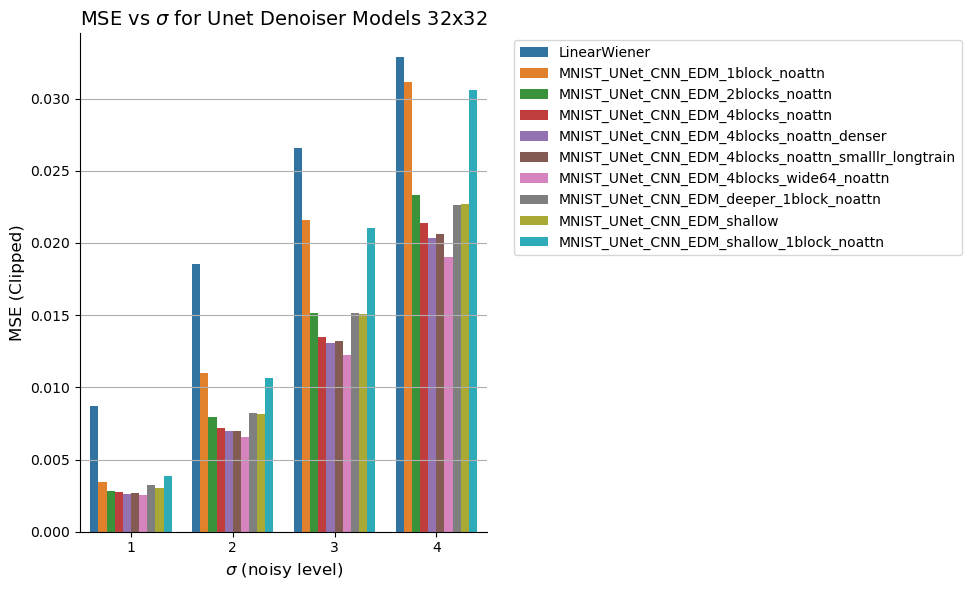

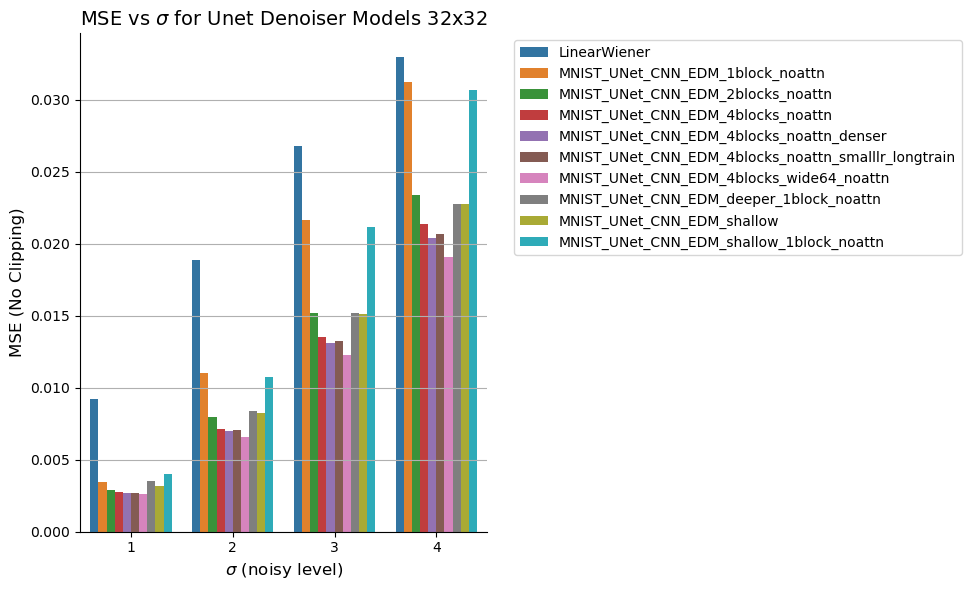

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the bar plot
plt.figure(figsize=(10, 6))
# Plot MSE_clip by sigma with different models as colors
sns.barplot(data=results_df, x='sigma', y='MSE_clip', hue='expname')
plt.title('MSE vs $\sigma$ for Unet Denoiser Models 32x32', fontsize=14)
plt.xlabel('$\sigma$ (noisy level)', fontsize=12)
plt.ylabel('MSE (Clipped)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()
# Also create a plot for MSE_noclip
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='sigma', y='MSE_noclip', hue='expname')
plt.title('MSE vs $\sigma$ for Unet Denoiser Models 32x32', fontsize=14)
plt.xlabel('$\sigma$ (noisy level)', fontsize=12)
plt.ylabel('MSE (No Clipping)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
# for expname in expnames:
# CNN_precd, model, config = load_pretrained_model(expname, device="cuda")
print(f"Loaded {expname} model")
print(f"Model config: {config}")
print("UNet denoiser")
Xprobe = Xtsr_raw[:2500]
noise_init = torch.randn(Xprobe_emma_norm.shape, generator=torch.Generator(device=device).manual_seed(seed), device=device)
Xprobe_emma_norm = mnist_normalize(Xprobe)
for sigma in [1, 2, 3, 4]:
    Xnoised_emma_norm = (Xprobe_emma_norm + sigma * noise_init)
    Xnoised = mnist_denormalize(Xnoised_emma_norm)
    Xnoised_BW_norm = mine_normalize(Xnoised)
    Xnoised_BW_denorm = mine_denormalize(Xnoised_BW_norm)
    with torch.no_grad():
        sigma_vec = torch.ones(Xnoised_BW_norm.shape[0], device=device) * sigma
        denoised_X_BW_norm = CNN_precd(Xnoised_BW_norm, sigma_vec)
        denoised_X_BW_denorm = mine_denormalize(denoised_X_BW_norm)
    torch.cuda.empty_cache()
    MSE_noclip = (denoised_X_BW_denorm - Xprobe).pow(2).mean()
    MSE_clip = (denoised_X_BW_denorm.clamp(0, 1) - Xprobe).pow(2).mean()
    print(f"sigma {sigma}", "MSE (noclip)", MSE_noclip.item(), "MSE (clip)", MSE_clip.item())
    
    # Append results to list
    result_row = {
        'expname': "Linear Wiener",
        'sigma': sigma,
        'MSE_noclip': MSE_noclip.item(),
        'MSE_clip': MSE_clip.item()
    }
    results.append(result_row)
print("======================\n")

# # Convert to DataFrame for better organization
# results_df = pd.DataFrame(results)
# print("\nOrganized Results:")
# print(results_df.to_string(index=False))

Loaded MNIST_UNet_CNN_EDM_shallow_1block_noattn model
Model config: {'channels': 1, 'img_size': 32, 'layers_per_block': 2, 'attn_resolutions': [], 'decoder_init_attn': False, 'model_channels': 32, 'channel_mult': [1], 'dropout': 0.0, 'label_dim': 0, 'augment_dim': 0}
UNet denoiser
sigma 1 MSE (noclip) 0.0039884671568870544 MSE (clip) 0.003837467171251774
sigma 2 MSE (noclip) 0.010773240588605404 MSE (clip) 0.010656112805008888
sigma 3 MSE (noclip) 0.021128807216882706 MSE (clip) 0.021028457209467888
sigma 4 MSE (noclip) 0.03068694658577442 MSE (clip) 0.030591866001486778

